# **Seminar 2: Transformer Architecture

**Ashish Vaswani** and Noam Shazeer and Niki Parmar and Jakob Uszkoreit and Llion Jones and Aidan N. Gomez and Lukasz Kaiser and Illia Polosukhin. [*Attention is all you need*](https://arxiv.org/abs/1706.03762). NeurIPS 2017.

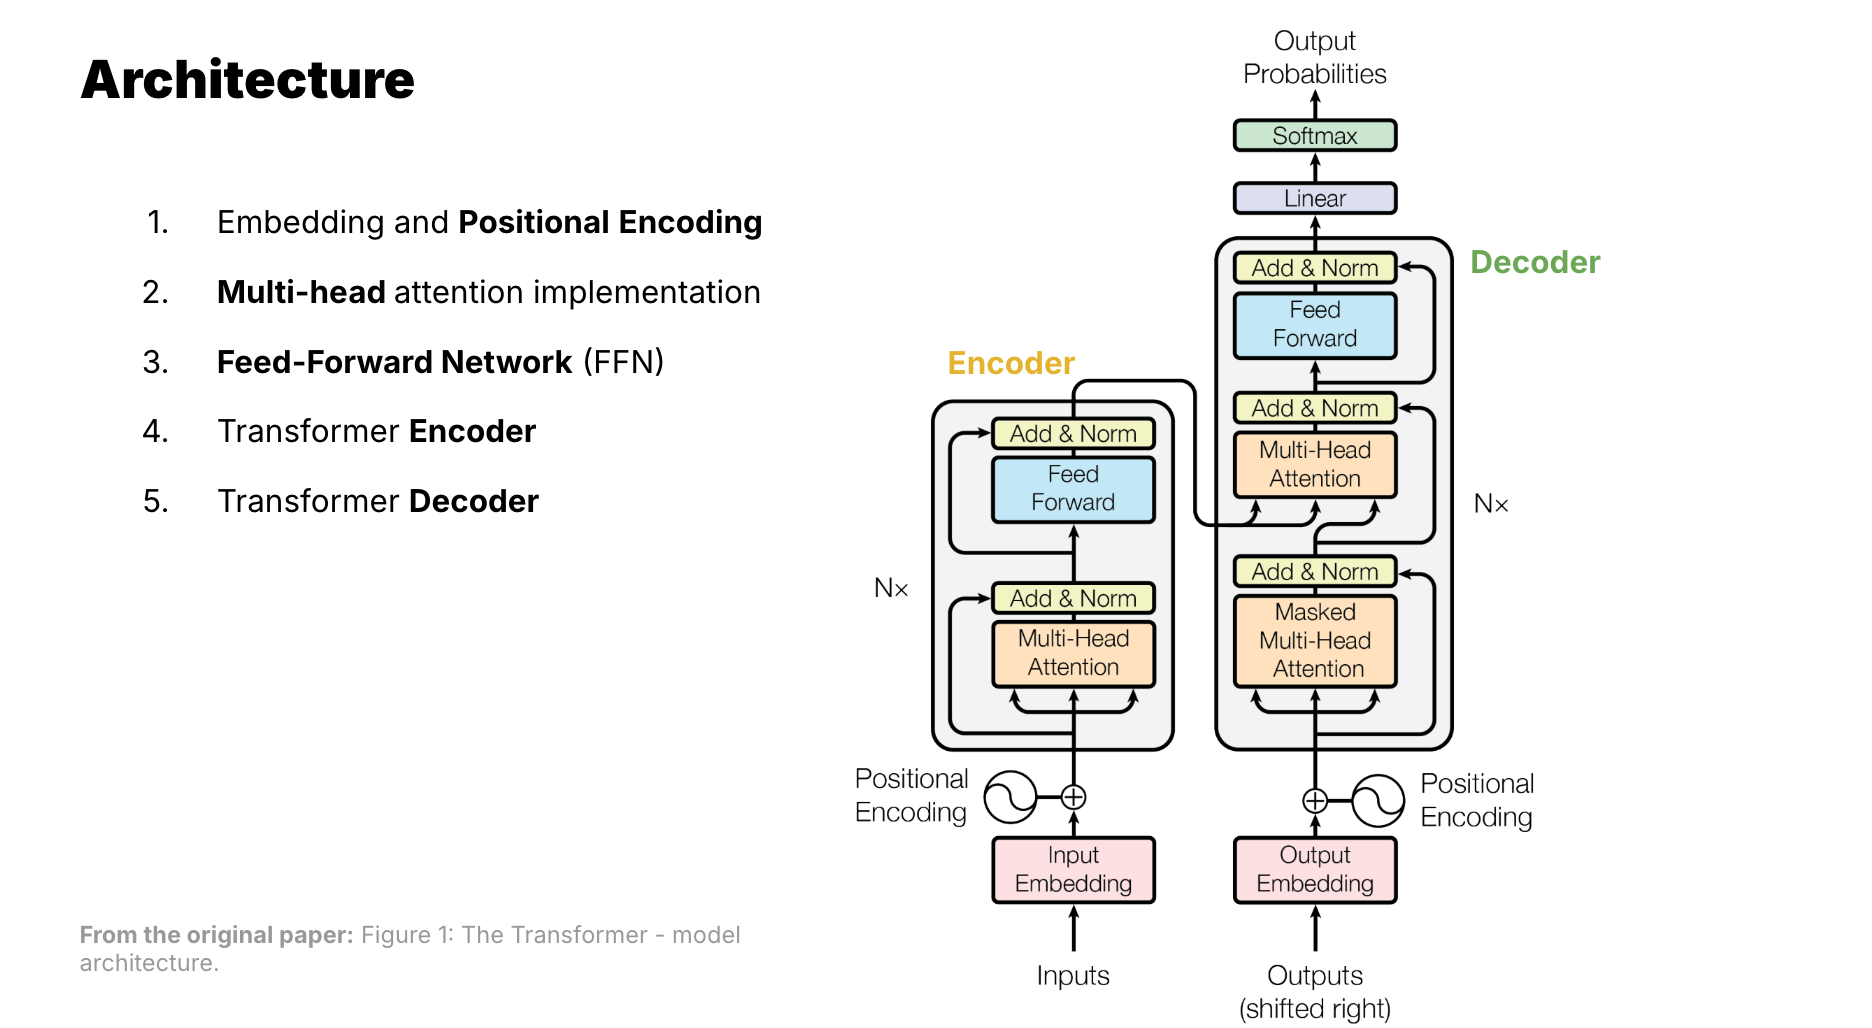

## **1. Embedding and Positional Encoding**
*Sections 3.4-3.5 of the original paper*

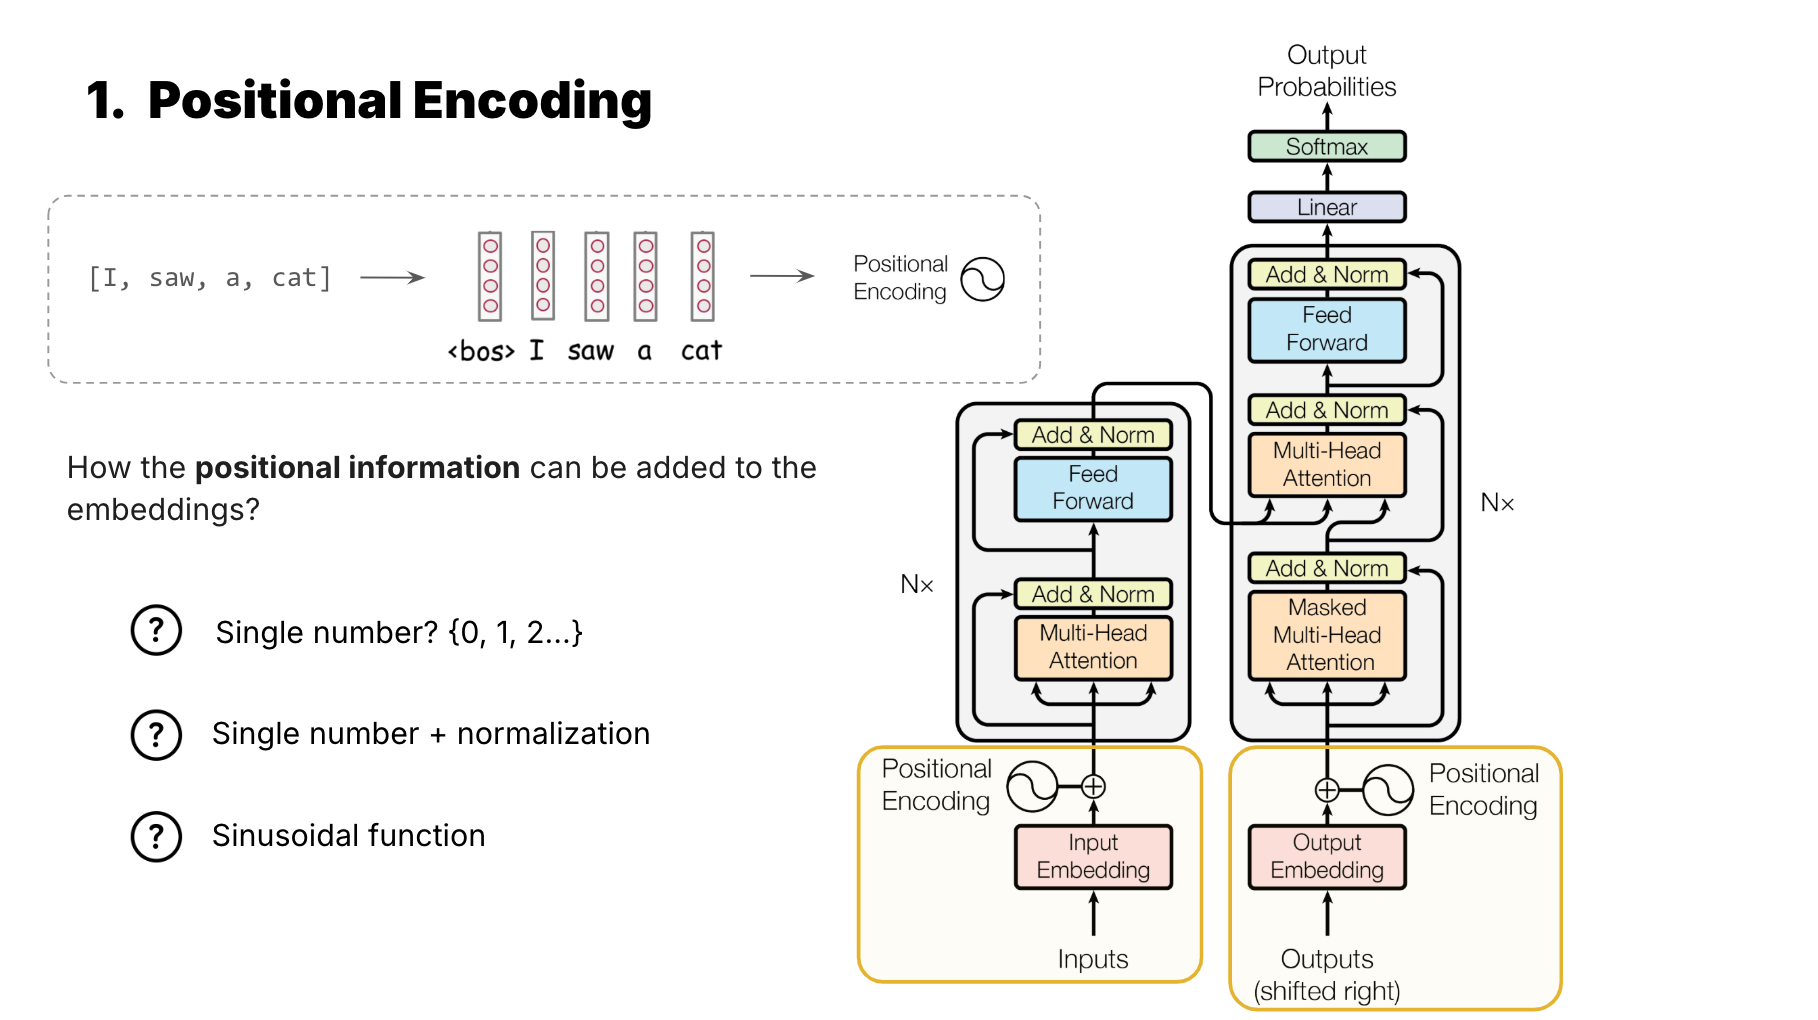

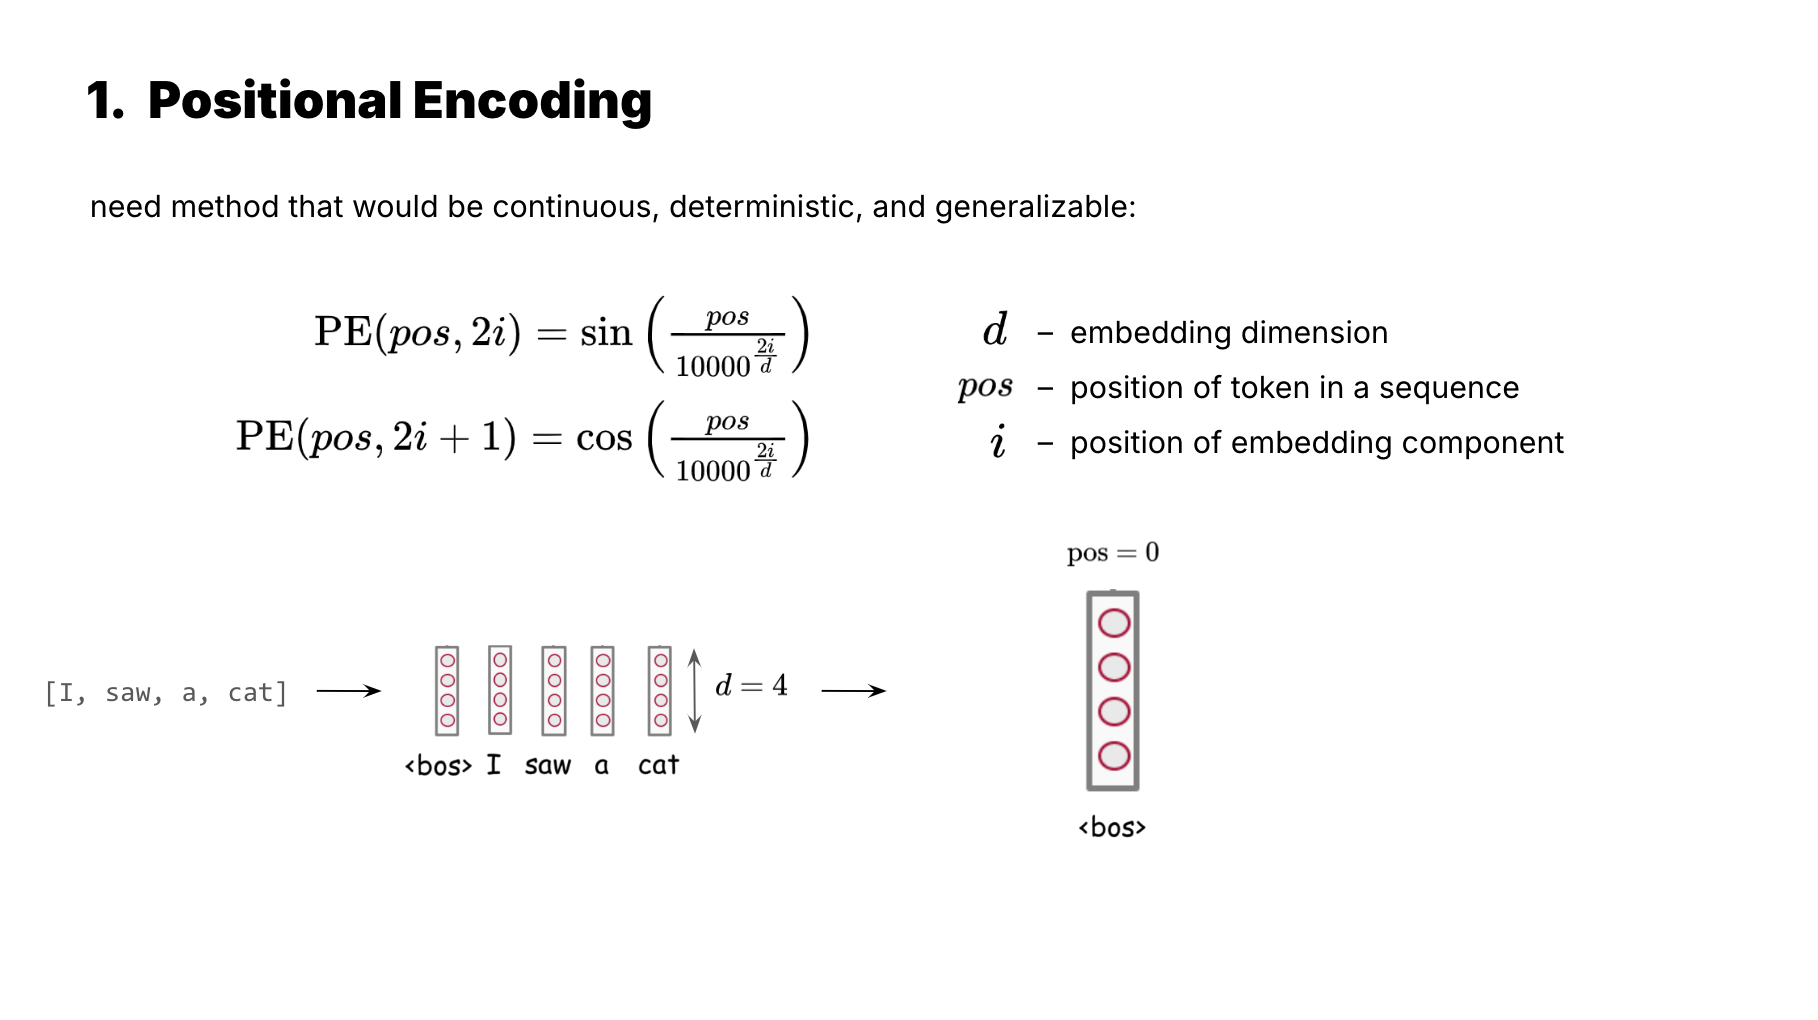

### **1.1. Implementation**

In [ ]:
import math
import torch
import torch.nn as nn


class EmbeddingWithProjection(nn.Module):
    def __init__(self, vocab_size, d_embed, d_model, dropout=0.1):
        super().__init__()
        # Store d_model, d_embed, vocab_size. Create: embeddings, projection, layernorm, dropout.
        self.d_model = d_model
        self.d_embed = d_embed
        self.vocab_size = vocab_size
        #self.dropout = dropout

        self.embeddings = nn.Embedding(vocab_size ,d_embed)
        self.projection = nn.Linear(d_model, d_model)

        self.layer_norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)




    @staticmethod
    def create_positional_encoding(seq_length, d_model, batch_size=1, device=None):
        # Sinusoidal positional encoding: build (seq_length, d_model), then expand to (batch_size, seq_length, d_model). Use sin for even indices, cos for odd.
        pe = torch.zeros(seq_length, d_model)
        position = torch.arange(seq_length, dtype=torch.float32).unsqueeze(1)
        
        div_item = torch.exp(
            torch.arange(0, d_model , dtype=torch.float32)*(-torch.log(torch.tensor(10000.0)) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_item)

        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position*div_item[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_item)

        pe = pe.unsqueeze(0)
        pe = pe.expand(batch_size, -1, -1)
        
        return pe  # tensor of shape (batch_size, seq_length, d_model)

    def forward(self, x):
        # x: (batch_size, seq_len). Return: (batch_size, seq_len, d_model).
        # Embed -> project -> add positional encoding -> LayerNorm -> dropout.
        batch_size, seq_len = x.shape

        x = self.embeddings(x)
        x = self.projection(x)

        pe = self.create_positional_encoding(
            seq_length=seq_len,
            d_model=self.d_model,
            batch_size=batch_size,
            device=x.device
        )

        x = x + pe
        x = self.layer_norm(x)
        x = self.dropout(x)

        return x

### **1.2. Analysis & Interpretation**

1. dependence of the heatmap on the embedding size `d` $-$ the frequency of functions increases with increasing `d`
2. dependence of heatmap on the maximum number of tokens `pos` $-$ reproducibility


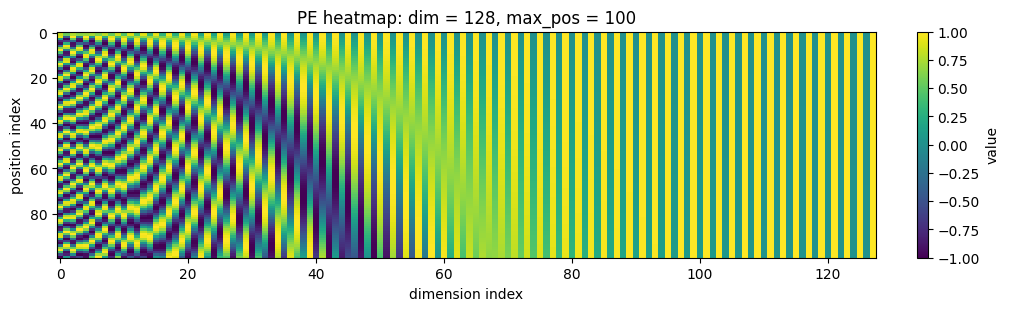

In [ ]:
import math
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.constrained_layout.use'] = True


ds = [128]
max_poses = [100]

for d in ds:
  for max_pos in max_poses:
    pe_demo = EmbeddingWithProjection.create_positional_encoding(
        seq_length=max_pos,
        d_model=d
    )[0]

    plt.figure(figsize=(10, 3))
    plt.title(f"PE heatmap: dim = {d}, max_pos = {max_pos}")
    plt.imshow(pe_demo, aspect='auto', interpolation='nearest')
    plt.xlabel("dimension index")
    plt.ylabel("position index")
    plt.colorbar(label="value")
    plt.show()

## **2. Multi-Head Attention Blocks**
*Section 3.2 of the original paper*


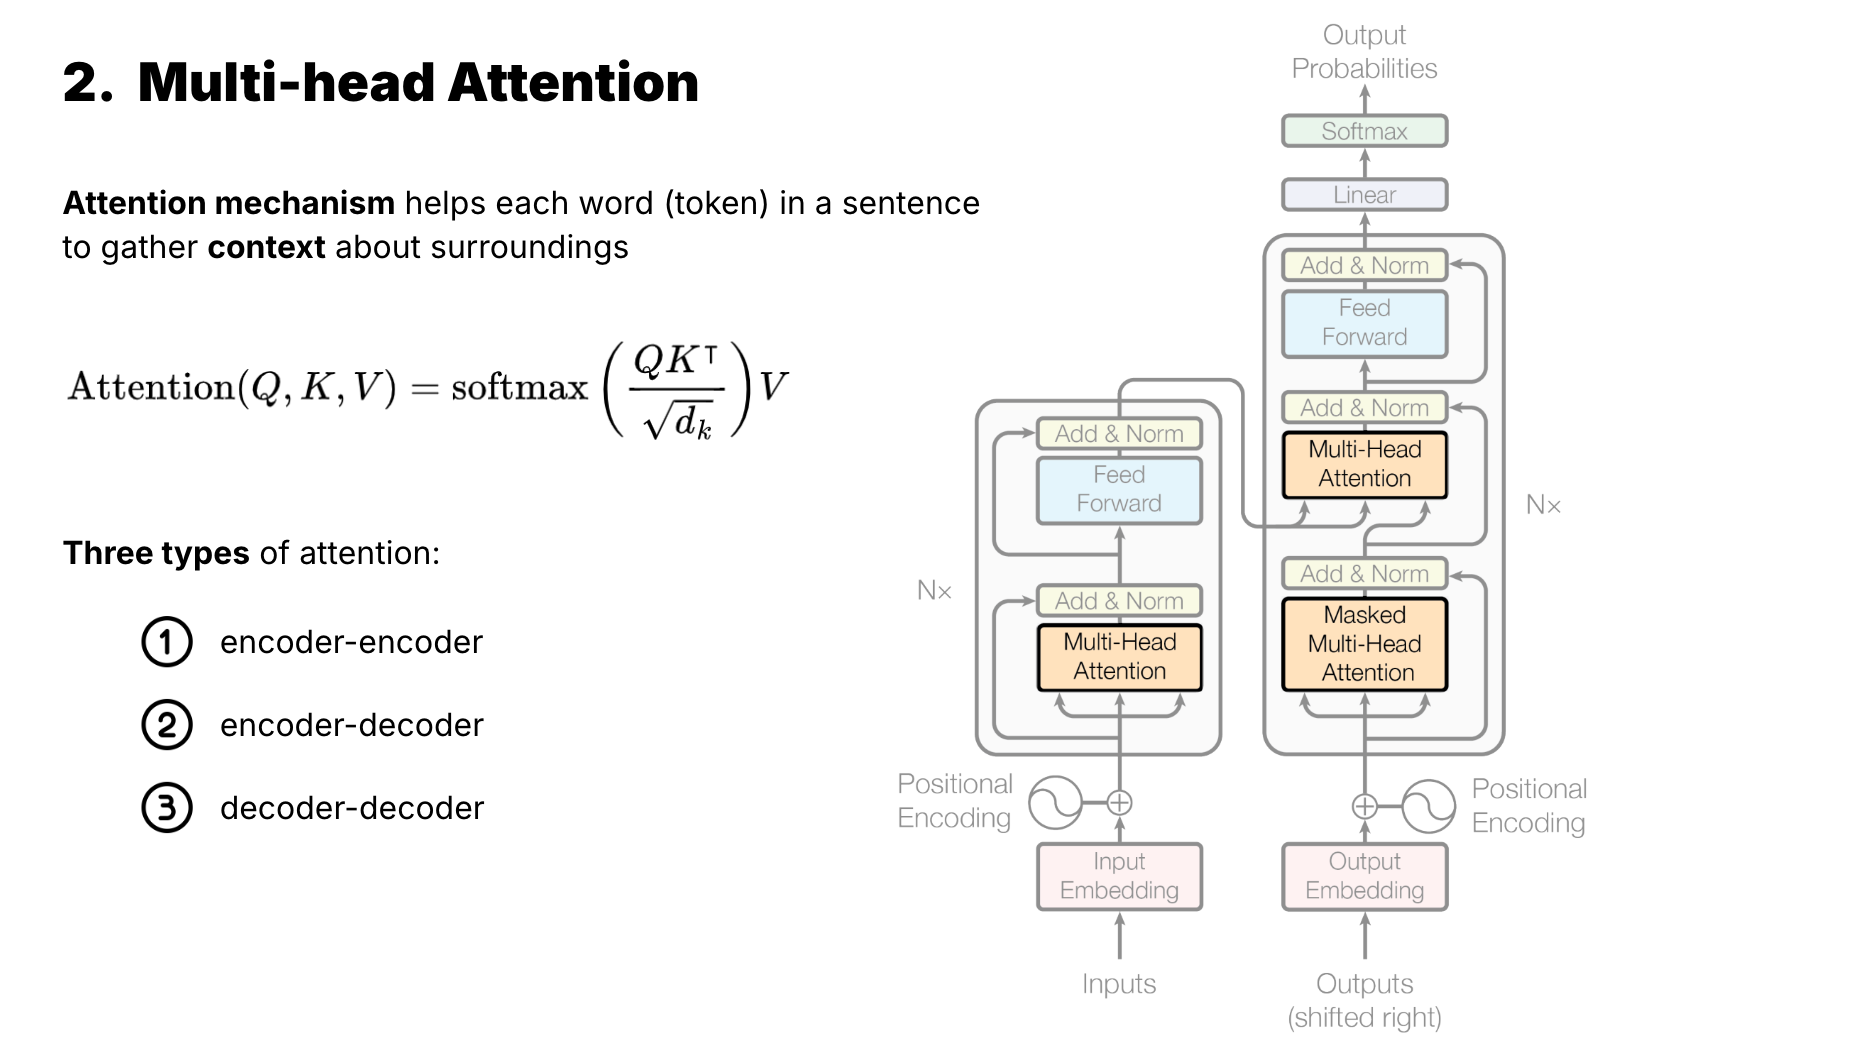

### **2.2. Multi-Head Attention**
*Section 3.2.2 of the original paper*

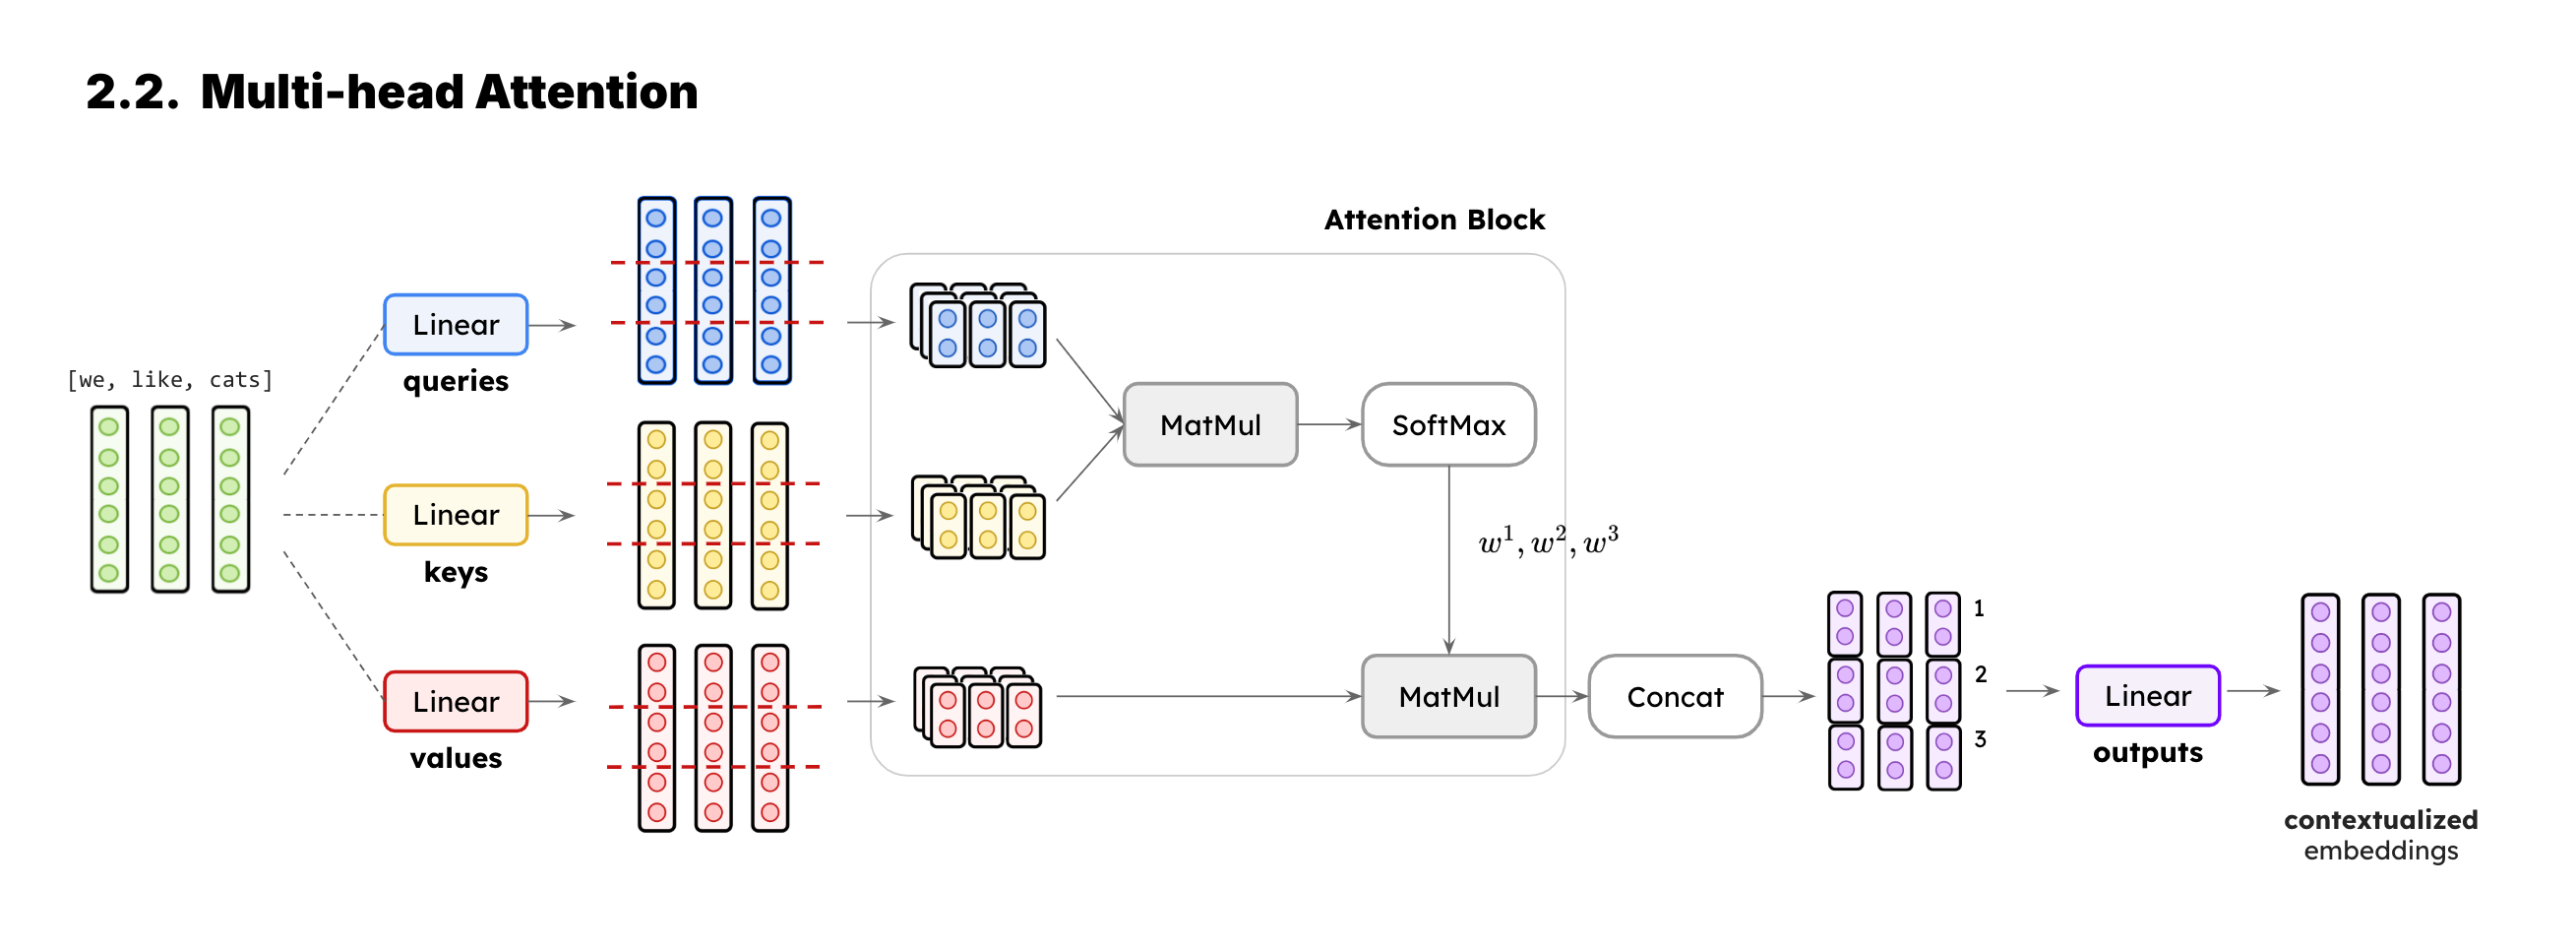

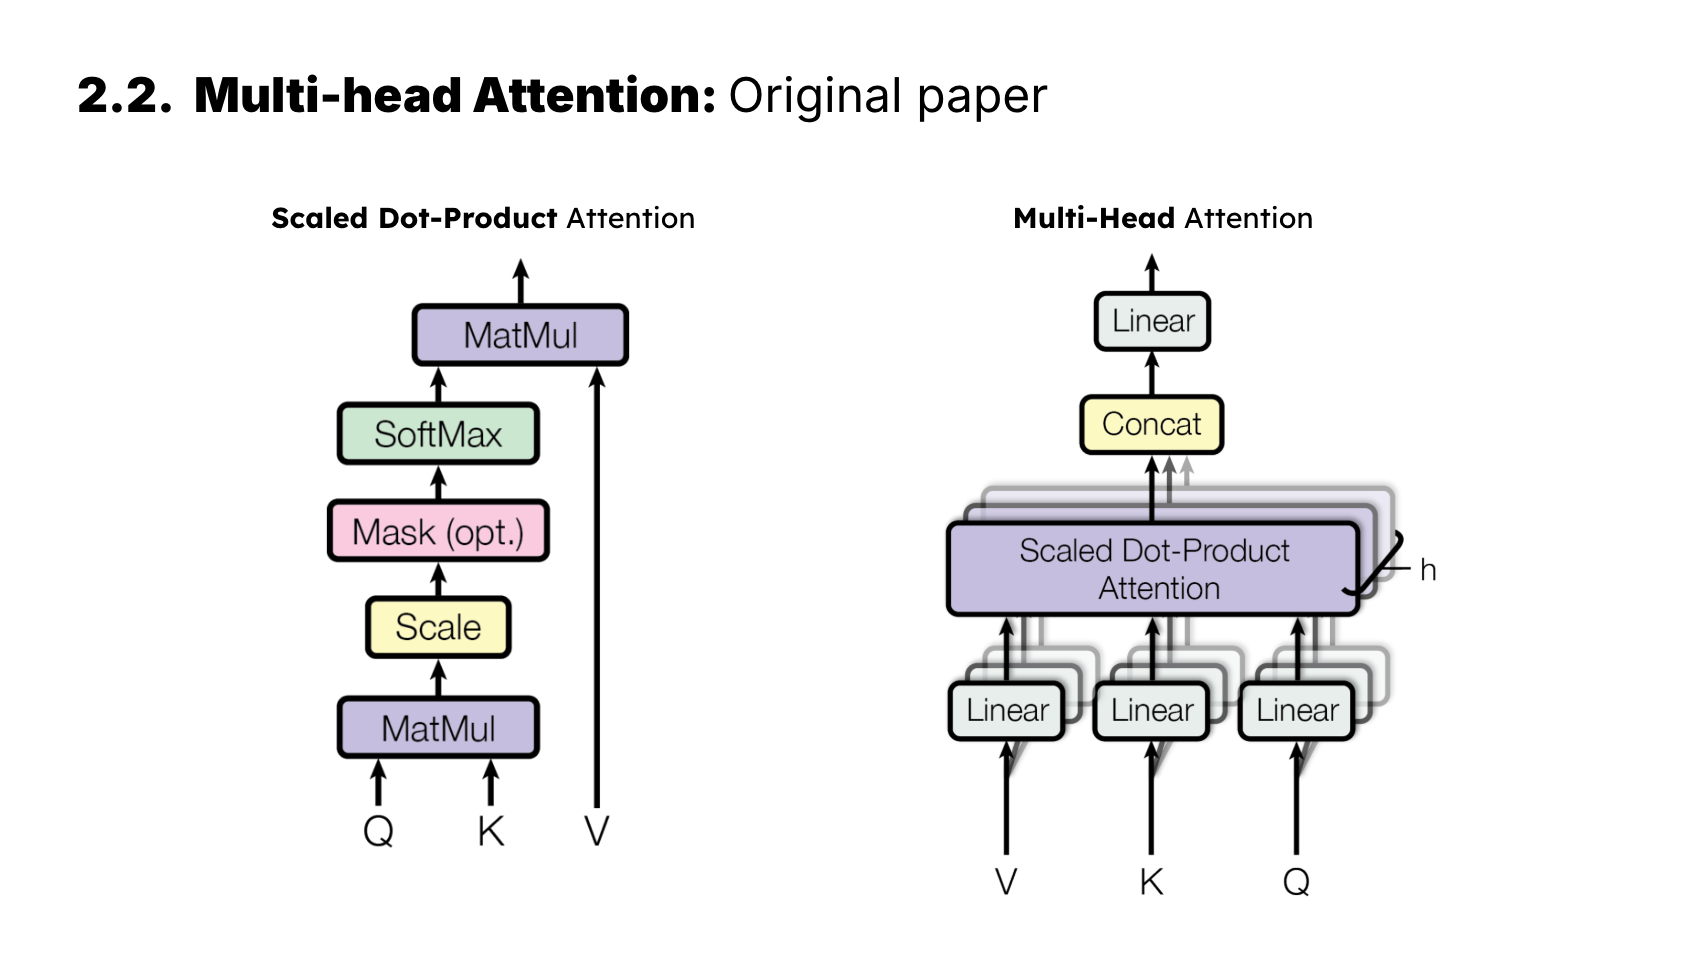

### **2.3. Implementation**


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import math


class TransformerAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1, bias=True):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        # Store d_model, num_heads, d_head = d_model // num_heads. Create W_q, W_k, W_v, W_o (Linear), scaling = 1/sqrt(d_head), dropout.
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_head = d_model // num_heads
        self.scaling = 1 / math.sqrt(self.d_head)

        self.W_q = nn.Linear(d_model, d_model, bias = bias)
        self.W_k = nn.Linear(d_model, d_model, bias = bias)
        self.W_v = nn.Linear(d_model, d_model, bias = bias)
        self.W_o = nn.Linear(d_model, d_model, bias = bias)

        self.dropout = nn.Dropout(dropout)




    def _shape_heads(self, x: torch.Tensor) -> torch.Tensor:
        # [b, s, d_model] -> [b, s, num_heads, d_head] -> [b, num_heads, s, d_head]. Return contiguous tensor.
        batch_size , seq_len , _ = x.shape
        x = x.reshape(batch_size, seq_len, self.num_heads, self.d_head)
        return  x.transpose(1,2).contiguous()# (b, num_heads, s, d_head)

    def forward(self, sequence, key_value_states=None, attn_mask=None):
        # sequence: (batch_size, seq_len, d_model). key_value_states=None for self-attn, else for cross-attn.
        # Compute Q from sequence; K,V from key_value_states or sequence. Scale dot-product, apply attn_mask, softmax, dropout, then output projection. Return (batch_size, seq_len, d_model).
        batch_size , seq_len , _ = sequence.shape
        Q = self.W_q(sequence)

        if key_value_states is None :
            K = self.W_k(sequence)
            V = self.W_v(sequence)
        else:
            K = self.W_k(key_value_states)
            V = self.W_v(key_value_states)
        Q = self._shape_heads(Q)
        K = self._shape_heads(K)
        V = self._shape_heads(V)

        scores = torch.matmul(Q, K.transpose(-2,-1)) * self.scaling

        if attn_mask is not None:
            scores = scores + attn_mask
        
        attn_weight = F.softmax(scores, dim=-1)
        attn_weight = self.dropout(attn_weight)

        context = context.transpose(1,2).contigous()
        context = context.reshape(batch_size, seq_len, self.d_model)

        att_output = self.W_0(context)
        return att_output

## **3. Feed-Forward Network (FFN)**
*Section 3.3 of the original paper*

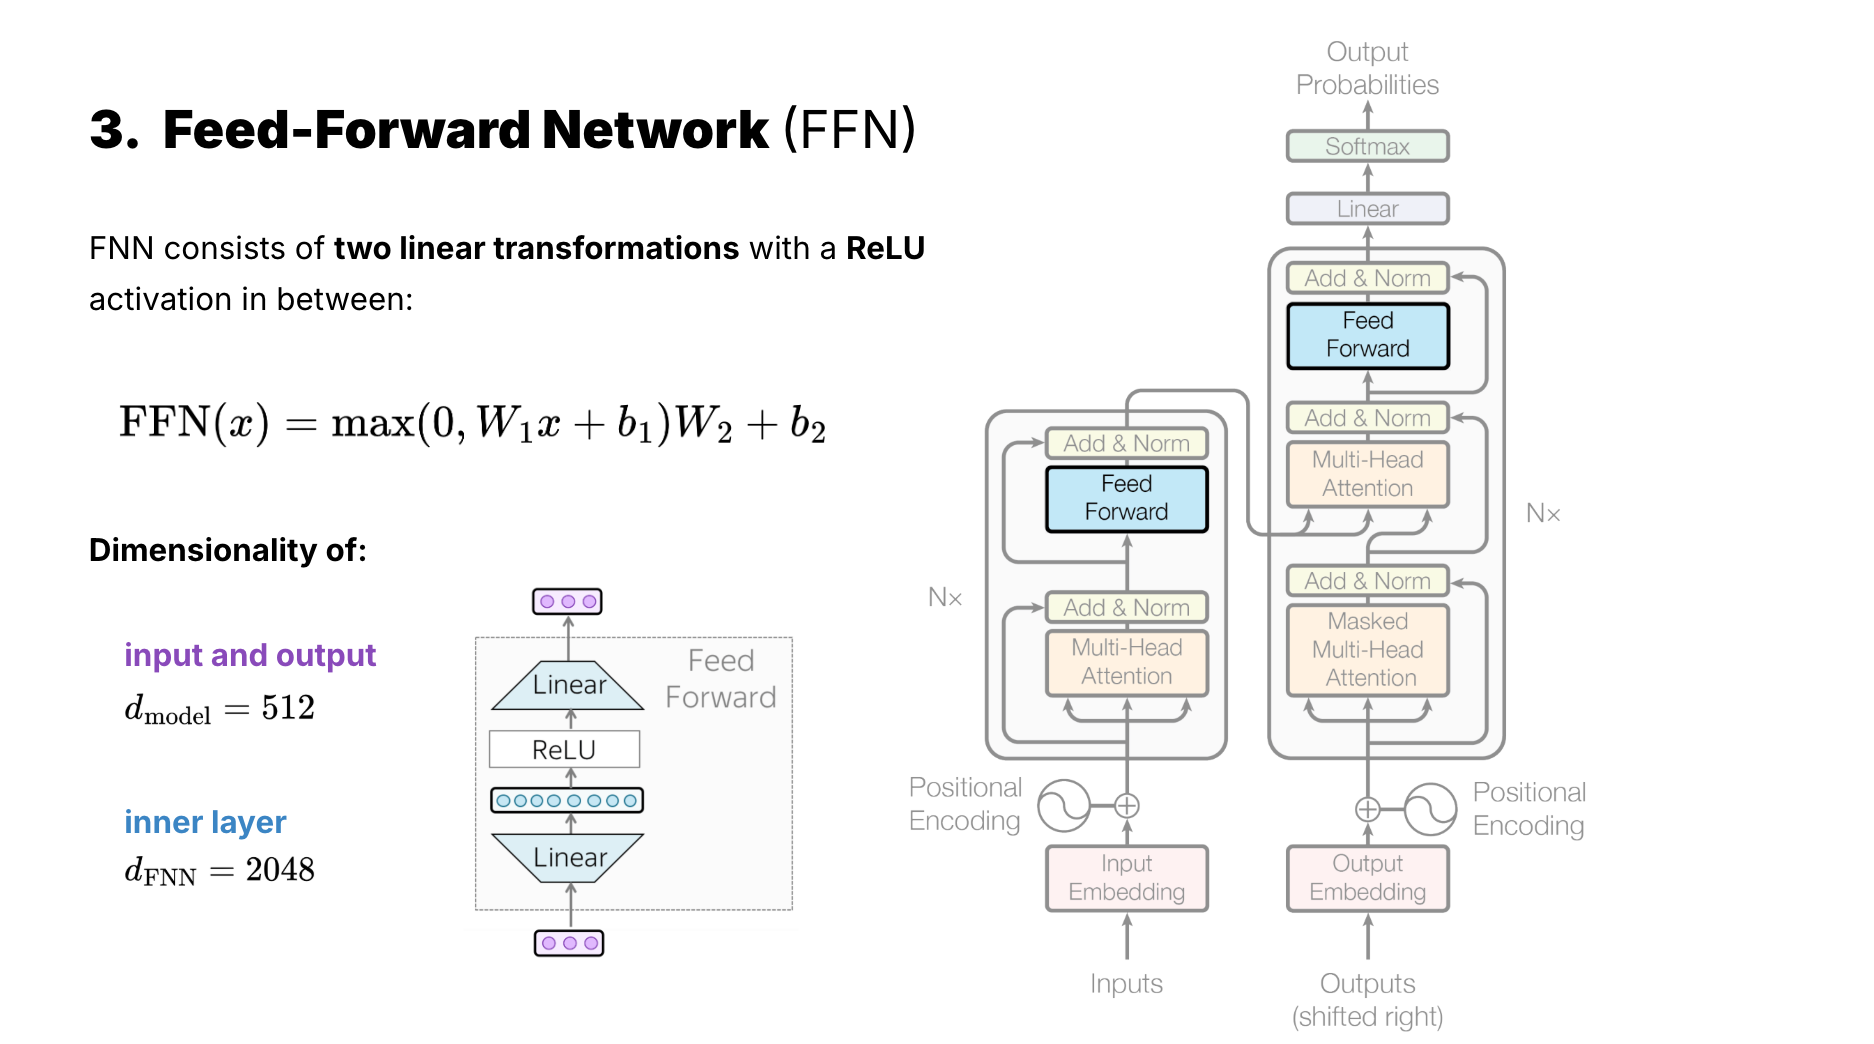

### **3.1. Implementation**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class FFN(nn.Module):
    def __init__(self, d_model, d_ffn):
        super().__init__()
        # Two linear layers: d_model -> d_ffn -> d_model (with bias). Optionally Xavier init.
        self.linear_1 = nn.Linear(d_model,d_ffn)
        self.linear_2 = nn.Linear(d_ffn , d_model)

        nn.init.xavier_uniform_(self.linear_1)
        nn.init.xavier_uniform_(self.linear_2)

        self.relu = nn.ReLU()

    def forward(self, x):
        # x: (batch_size, seq_length, d_model). Apply fc1 -> ReLU -> fc2. Return same shape.
        output = self.linear_1(x)
        output = self.relu(output)
        output = self.linear_2(output)

        return output

## **4. Transformer Encoder**
*Section 3.1 of the original paper*

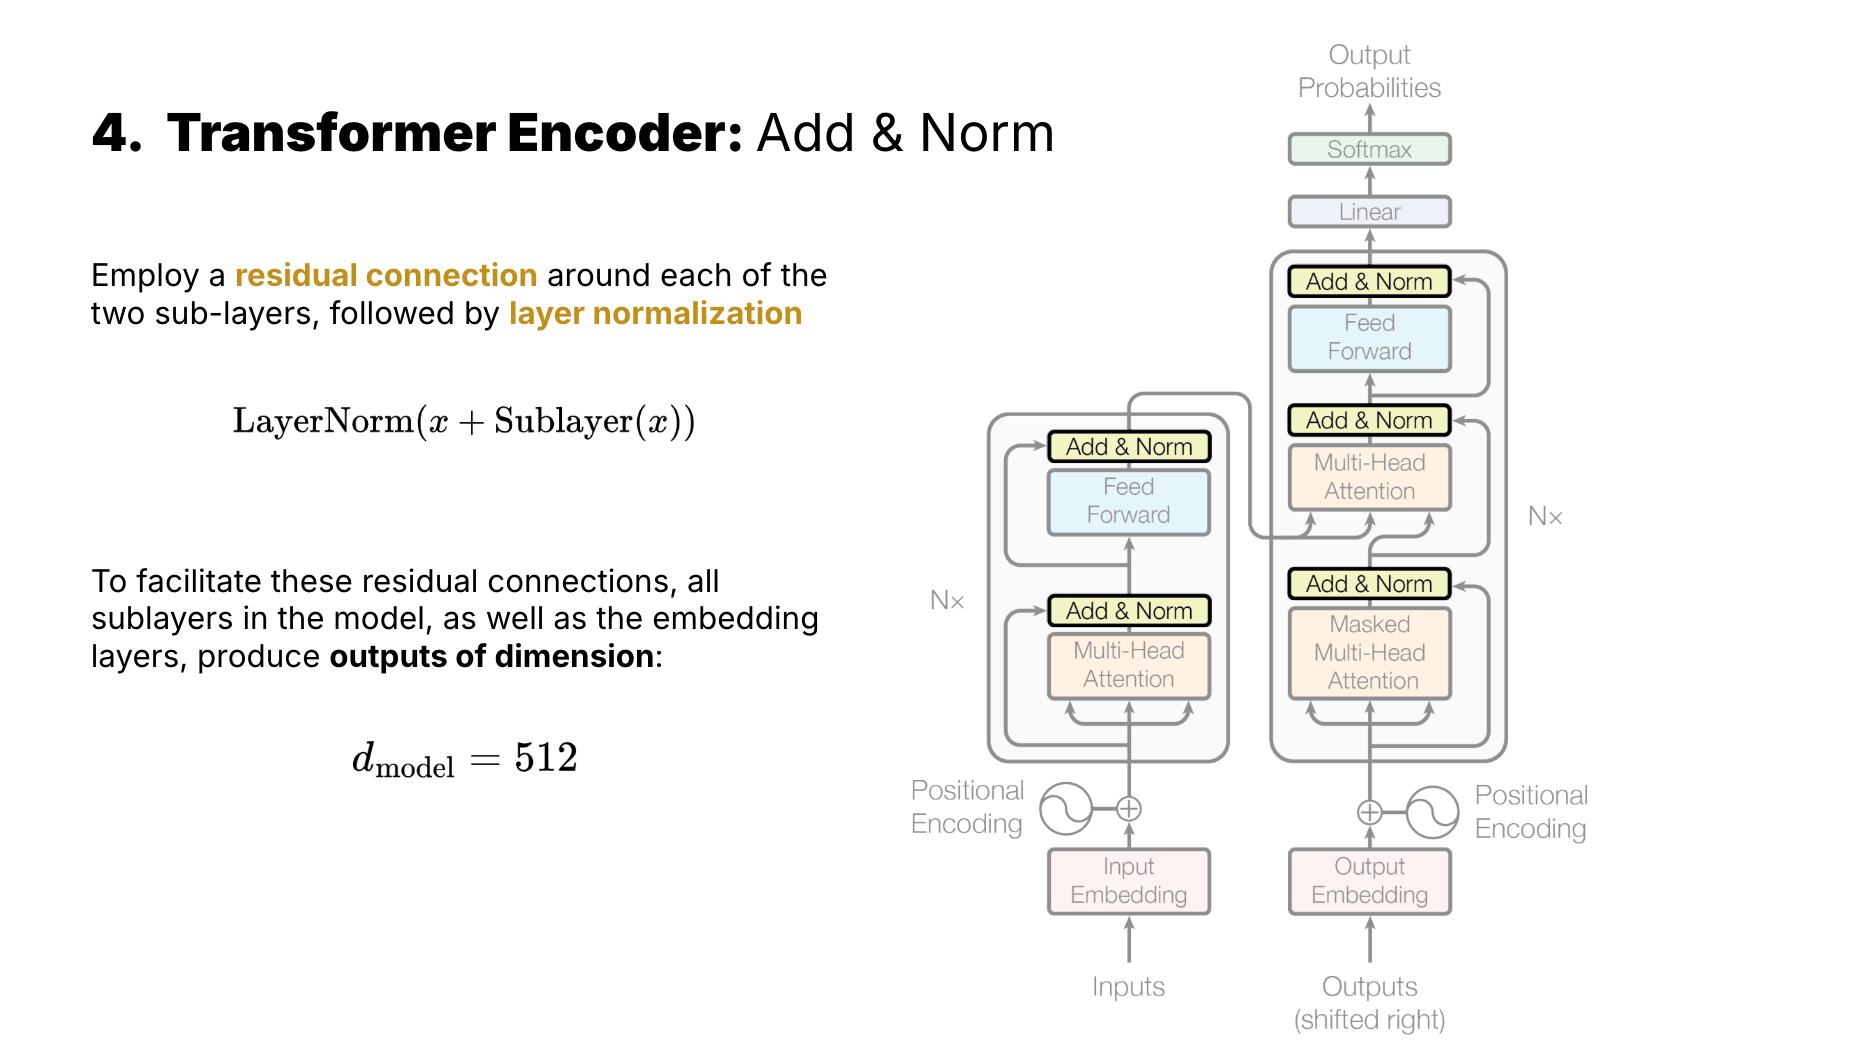

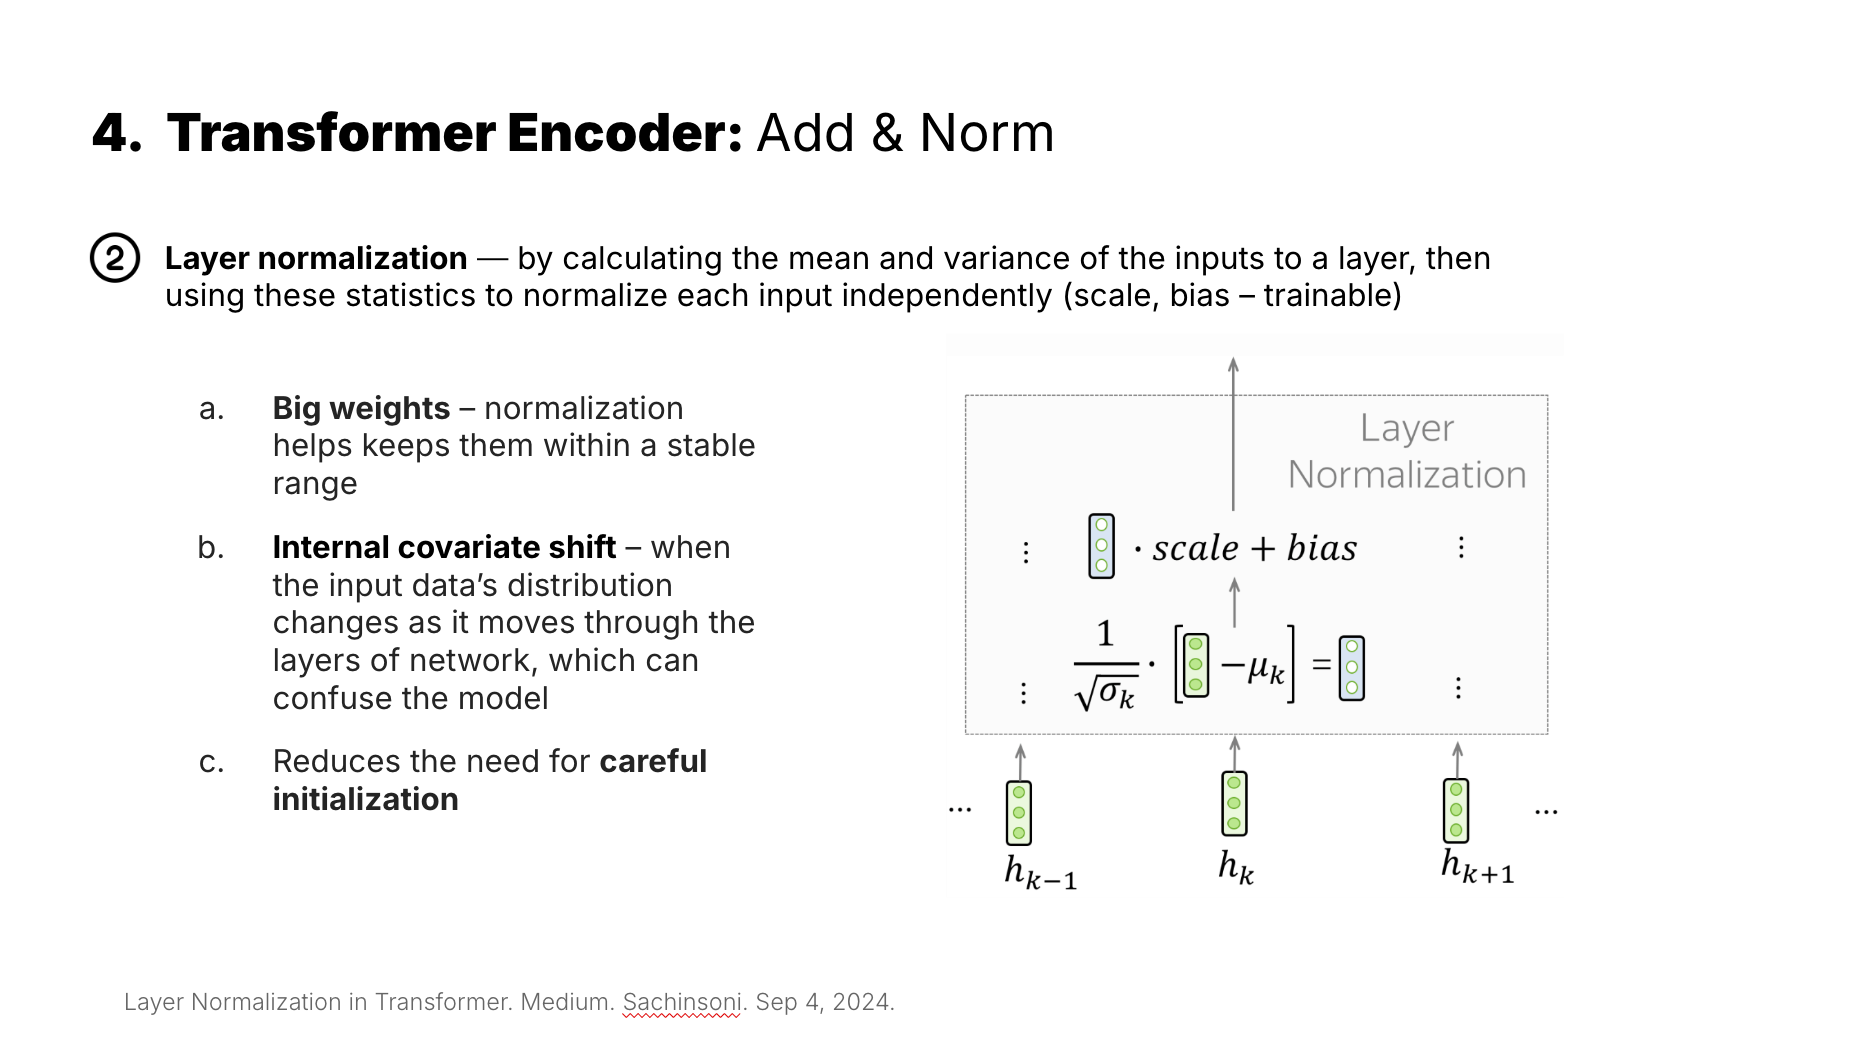

### **4.1. Implementation**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class TransformerEncoder(nn.Module):
    def __init__(self, d_model, d_ffn, num_heads, dropout=0.1, bias=True):
        super().__init__()
        # One self-attention (TransformerAttention), one FFN, two LayerNorms, dropout. Store d_model, d_ffn.
        <YOUR CODE HERE>

    def forward(self, x, padding_mask=None):
        # x: (batch_size, seq_len, d_model). One encoder layer: self-attn (with padding_mask) -> add & norm -> FFN -> add & norm. Return same shape.
        <YOUR CODE HERE>
        return ffn_normalized

## **5. Transformer Decoder**
*Section 3.1 of the original paper*

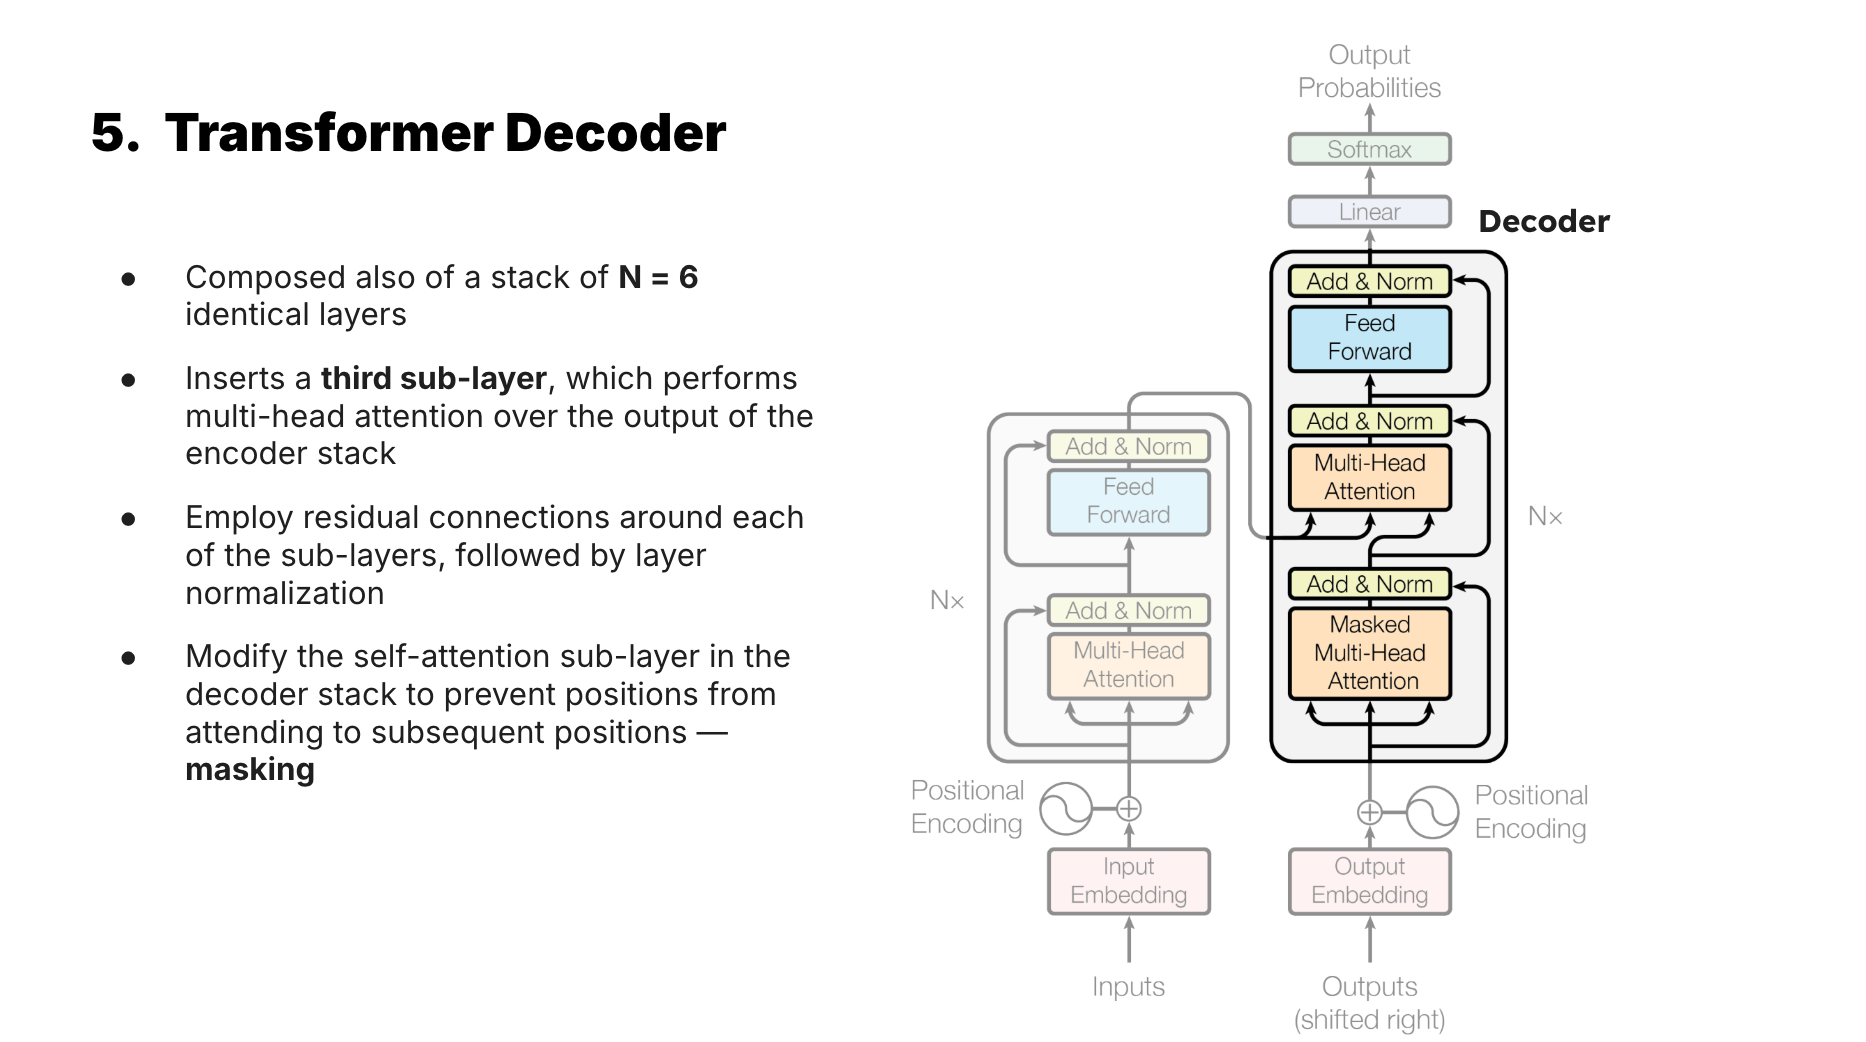

### **5.1. Implementation**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class TransformerDecoder(nn.Module):
    def __init__(self, d_model, d_ffn, num_heads, dropout=0.1, bias=True):
        super().__init__()
        # Two attentions (att1 self-attn, att2 cross-attn), one FFN, three LayerNorms, dropout. Store d_model, d_ffn.
        <YOUR CODE HERE>

    @staticmethod
    def create_causal_mask(seq_len, device=None):
        # Upper triangular mask (causal): positions (i, j) with j > i should be -inf. Return (seq_len, seq_len).
        <YOUR CODE HERE>
        return ...  # (seq_len, seq_len)

    def forward(self, x, cross_input, padding_mask=None):
        # x: decoder hidden (B, dec_len, d_model). cross_input: encoder output (B, enc_len, d_model).
        # Build causal (+ optional padding) mask for self-attn. Then: masked self-attn -> add & norm -> cross-attn (with cross_input, padding_mask) -> add & norm -> FFN -> add & norm. Return (B, dec_len, d_model).
        <YOUR CODE HERE>
        return ffn_normalized

## **6. Encoder-Decoder Stack**
*Section 3.1 of the original paper*

### **6.1. Implementation**

In [ ]:
class TransformerEncoderDecoder(nn.Module):
    def __init__(self, num_layer, d_model, d_ffn, num_heads, dropout=0.1, bias=True):
        super().__init__()
        # Build encoder_stack (ModuleList of num_layer TransformerEncoder) and decoder_stack (ModuleList of num_layer TransformerDecoder).
        <YOUR CODE HERE>

    def forward(self, embed_encoder_input, embed_decoder_input, padding_mask=None):
        # Run encoder stack on embed_encoder_input; then run decoder stack with embed_decoder_input and encoder output. Return decoder output (B, dec_len, d_model).
        <YOUR CODE HERE>
        return decoder_output

## **7. Full Transformer!**

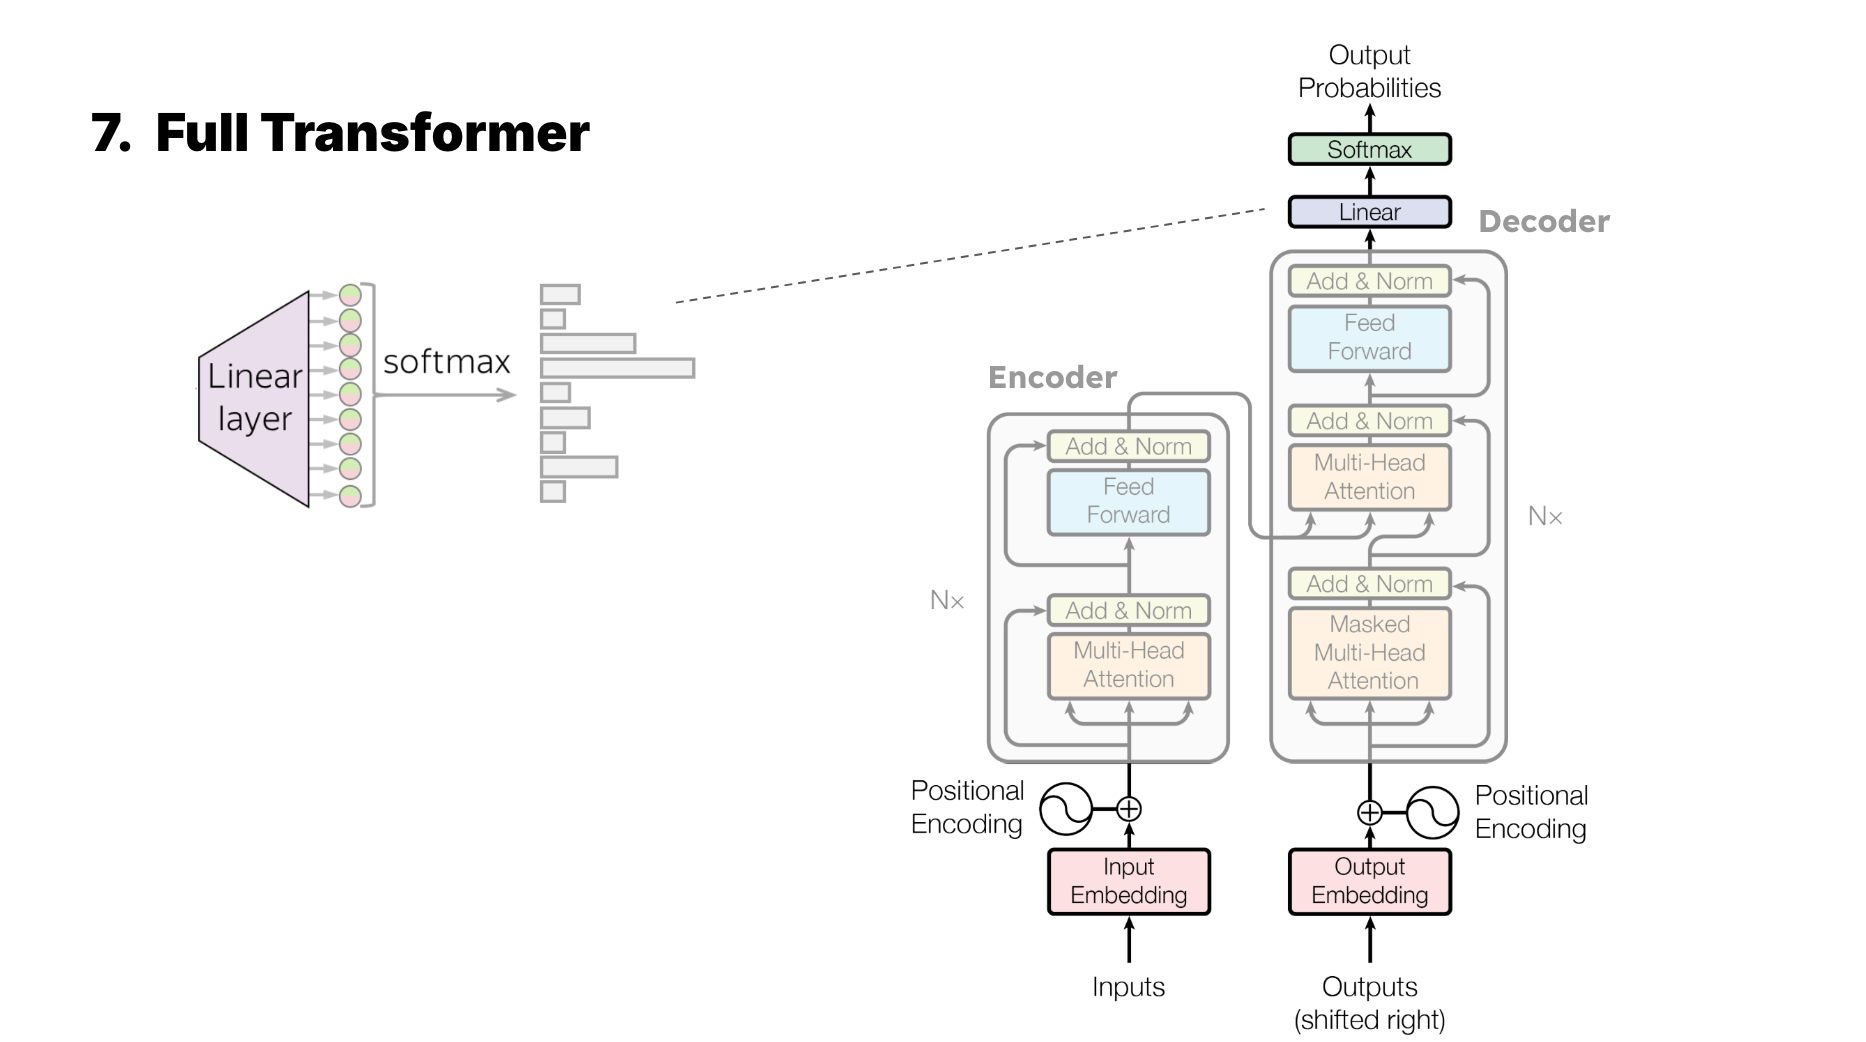

In [ ]:
class Transformer(nn.Module):
    def __init__(
        self,
        num_layer,
        d_model,
        d_embed,
        d_ffn,
        num_heads,
        src_vocab_size,
        tgt_vocab_size,
        max_position_embeddings=512,
        dropout=0.1,
        bias=True
    ):
        super().__init__()
        # Create src_embeddings and tgt_embeddings (EmbeddingWithProjection), encoder_decoder (TransformerEncoderDecoder), output_projection (Linear d_model -> tgt_vocab_size), LogSoftmax(dim=-1).
        <YOUR CODE HERE>

    def shift_target_right(self, tgt_tokens):
        # Prepend a zero/BOS token and drop last position so decoder sees previous targets. Return (batch_size, seq_len) same dtype/device as tgt_tokens.
        <YOUR CODE HERE>
        return shifted_tokens

    def forward(self, src_tokens, tgt_tokens, padding_mask=None):
        # Shift target, embed src and tgt, run encoder_decoder, project to vocab and log_softmax. Return log_probs (B, dec_len, tgt_vocab_size).
        <YOUR CODE HERE>
        return log_probs
